# Talmud-Portfolio -- a quantitative teardown
### Real daily prices 2007-2026 . annual rebalance . HAC t-stats . crash anatomy

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![vs_60/40%3F: No_Edge](https://img.shields.io/badge/vs_60/40%3F-No__Edge-8b949e?style=flat-square)

The deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) -- same seven beats, every claim now carrying its standard error. We test whether the Talmud 1/3-1/3-1/3 blend (VNQ/SPY/BND) outperforms 60/40 (SPY/BND) on Sharpe, CAGR, and max drawdown over a 19-year real-data window, and diagnose why the REIT leg fails.

> **Not investment advice.** Real data: Yahoo Finance total-return prices, 2007-04-10 to 2026-06-11, as-of 2026-06-15. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The `> In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from talmud_portfolio import data, strategy as st

STUDY_CACHE = os.path.join(os.path.abspath(".."), "_cache", "talmud_prices.parquet")
SHARED_PANEL = os.path.join(os.path.abspath("../../.."), "_cache", "cross_asset_etfs.parquet")

def _have_cache():
    return os.path.exists(STUDY_CACHE) or os.path.exists(SHARED_PANEL)

HAVE_REAL = _have_cache()
print("real price cache present:", HAVE_REAL)

# Frozen real-tape headline numbers -- mirror of docs/results.md (as-of 2026-06-15).
R = dict(
    n_days=4825, n_years=19.1,
    tal_cagr=6.9, tal_sharpe=0.31, tal_vol=14.6, tal_mdd=-44.0, tal_worst=-22.3,
    s60_cagr=8.1, s60_sharpe=0.46, s60_vol=11.5, s60_mdd=-33.8, s60_worst=-19.3,
    spy_cagr=10.9, spy_sharpe=0.45, spy_vol=19.7, spy_mdd=-55.2, spy_worst=-36.8,
    vnq_cagr=8.3, vnq_sharpe=0.32, vnq_mdd=-62.6,
    t_vs_6040=-1.26, t_vs_spy=-3.03, t_vs_vnq=-1.95,
    gfc_spy=-55.2, gfc_vnq=-69.3, gfc_bnd=7.5,
    covid_spy=-33.7, covid_vnq=-41.5, covid_bnd=-1.4,
    rate22_spy=-24.5, rate22_vnq=-31.9, rate22_bnd=-14.5,
)

if HAVE_REAL:
    prices = data.load_real()
    ret = st.to_returns(prices)
    rf = ret["BND"]
    tal   = st.talmud_portfolio(ret, cost_bps=10.0)
    s6040 = st.sixty_forty(ret, cost_bps=10.0)
    spy   = st.spy_only(ret)
    vnq50 = st.spy_vnq_50_50(ret, cost_bps=10.0)
    s_tal  = st.portfolio_stats(tal, rf=rf)
    s_6040 = st.portfolio_stats(s6040, rf=rf)
    s_spy  = st.portfolio_stats(spy, rf=rf)
    s_vnq  = st.portfolio_stats(vnq50, rf=rf)
    print(f"Loaded {len(prices)} days ({prices.index[0].date()} -> {prices.index[-1].date()})")


real price cache present: True


Loaded 4825 days (2007-04-10 -> 2026-06-11)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Talmud Sharpe **0.31** (positive) but below 60/40 **0.46**; HAC *t*(Talmud vs 60/40) = **-1.26** (not significant; n = 19 annual obs). |
| **Tradability** | `FRAGILE` | Tradable but dominated: CAGR **6.9%** vs 60/40 **8.1%**, max DD **-44.0%** vs **-33.8%**. |
| **vs 60/40?** | `NO EDGE` | VNQ fell **-69.3%** in the GFC (SPY fell -55.2%); every major crash has the same pattern. |

> In plain words: the Talmud allocation is a reasonable diversified portfolio, but the 'land' leg (VNQ) is a REIT ETF that behaves like levered equity in crises -- not the physical property the ancient text had in mind. Replacing 40 % of the bond hedge with REITs removes the only genuine hedge and adds correlated crash risk.

## 1 . The claim, steelmanned

Three testable hypotheses:

- **H1 (CAGR edge).** The Talmud blend earns a higher CAGR than 60/40 over long horizons because real estate adds a return premium that bonds don't.
- **H2 (risk reduction).** The Talmud has a lower max drawdown and higher Sharpe than 60/40 because REITs are less correlated with stocks than bonds.
- **H3 (crash hedge).** VNQ ('land') acts as a hedge during equity crises, cushioning the portfolio in the same way BND does.

We find **H1 false** (Talmud CAGR is lower), **H2 false** (max DD is deeper), and **H3 strongly false** (VNQ amplifies crashes). The ancient diversification insight is sound but the modern REIT proxy is the wrong instrument.

## 2 . So what? -- what rides on each answer

The Talmud portfolio is frequently cited in personal-finance content as a time-tested, authoritative allocation strategy. If the three hypotheses held, it would represent a genuinely superior alternative to 60/40 with 2,000 years of implicit out-of-sample validation. The interesting failure is **H3**: real estate has the *reputation* of uncorrelated diversifier, but REIT ETFs are highly equity-correlated in crises precisely because they trade like stocks (liquidity, margin calls, flight-to-quality selling) rather than like physical illiquid property.

## 3 . How we'd know -- the protocol

- **Universe.** VNQ (Vanguard Real Estate ETF), SPY (S&P 500), BND (Vanguard Total Bond Market). Window: 2007-04-10 (BND inception) to 2026-06-11.
- **Portfolios.** Talmud 1/3-1/3-1/3; 60/40 (SPY/BND); 100% SPY; 50/50 SPY/VNQ. All rebalanced annually at the first trading day of each calendar year, 10 bps one-way rebalance cost (two round trips per year per leg).
- **Total-return prices.** Yahoo Finance `auto_adjust=True` folds dividends and splits into the price series. This is essential for BND (coupon income) and VNQ (REIT distributions are a large fraction of return).
- **Inference.** HAC (Newey-West) t-stat on the annual return differential (Talmud minus benchmark); annual granularity avoids the daily-autocorrelation issue. n = 19 annual observations.
- **Sharpe.** Computed on excess-of-BND daily returns (BND as the cash proxy) for all arms, so the bond leg is consistently accounted for.
- **Positive control.** A deterministic synthetic three-asset tape with a tunable regime-cycle parameter confirms the engine recovers diversification benefits *when they exist*.

## 4 . The teardown

### 4a . Headline stats table

All portfolios at 10 bps one-way rebalance cost; Sharpe = excess-of-BND.

In [2]:

if HAVE_REAL:
    rows = [
        ("Talmud 1/3-1/3-1/3", s_tal['cagr']*100,  s_tal['sharpe'],  s_tal['vol']*100,
         s_tal['max_dd']*100,  s_tal['worst_year']*100),
        ("60/40 (SPY/BND)",      s_6040['cagr']*100, s_6040['sharpe'], s_6040['vol']*100,
         s_6040['max_dd']*100, s_6040['worst_year']*100),
        ("SPY 100%",             s_spy['cagr']*100,  s_spy['sharpe'],  s_spy['vol']*100,
         s_spy['max_dd']*100,  s_spy['worst_year']*100),
        ("SPY/VNQ 50/50",        s_vnq['cagr']*100,  s_vnq['sharpe'],  s_vnq['vol']*100,
         s_vnq['max_dd']*100,  s_vnq['worst_year']*100),
    ]
else:
    rows = [
        ("Talmud 1/3-1/3-1/3", R['tal_cagr'], R['tal_sharpe'], R['tal_vol'],R['tal_mdd'],R['tal_worst']),
        ("60/40 (SPY/BND)",     R['s60_cagr'], R['s60_sharpe'], R['s60_vol'],R['s60_mdd'],R['s60_worst']),
        ("SPY 100%",            R['spy_cagr'], R['spy_sharpe'], R['spy_vol'],R['spy_mdd'],R['spy_worst']),
        ("SPY/VNQ 50/50",       R['vnq_cagr'], R['vnq_sharpe'], np.nan,      R['vnq_mdd'],np.nan),
    ]
tbl = pd.DataFrame(rows, columns=["Portfolio","CAGR%","Sharpe","Vol%","MaxDD%","WorstYr%"])
tbl


,Portfolio,CAGR%,Sharpe,Vol%,MaxDD%,WorstYr%
0,Talmud 1/3-1/3-1/3,6.902473,0.310212,14.618457,-43.990298,-22.313494
1,60/40 (SPY/BND),8.146817,0.455239,11.515084,-33.757901,-19.332803
2,SPY 100%,10.900764,0.448127,19.727235,-55.189452,-36.795032
3,SPY/VNQ 50/50,8.282435,0.317491,22.939450,-62.581045,-36.896732


> In plain words: the Talmud delivers **6.9% CAGR** and Sharpe **0.31**; 60/40 delivers **8.1% CAGR** and Sharpe **0.46** on the same window. The Talmud also has a *deeper* max drawdown (-44.0% vs -33.8%). There is no axis on which the Talmud dominates 60/40.

### 4b . HAC t-stats on annual return differences

Newey-West inference on 19 annual observations. Two-sided test: does the Talmud significantly *outperform* or *underperform* each benchmark?

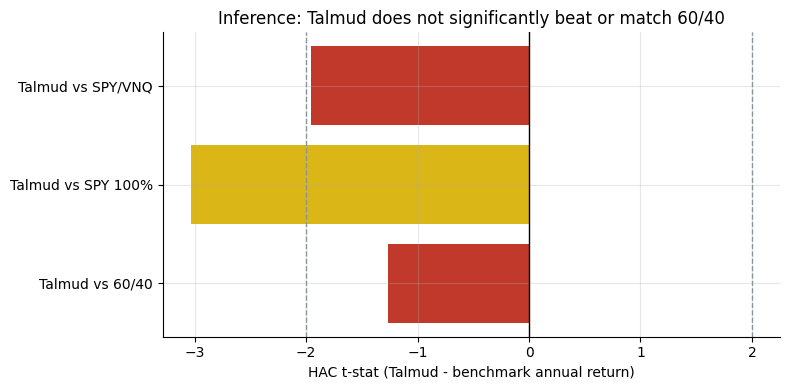

Talmud vs 60/40           t = -1.262  |t|<2:  no
Talmud vs SPY 100%        t = -3.033  |t|>=2: YES
Talmud vs SPY/VNQ         t = -1.952  |t|<2:  no


In [3]:

if HAVE_REAL:
    t_6040  = st.hac_tstat_annual(tal, s6040)
    t_spy   = st.hac_tstat_annual(tal, spy)
    t_vnq50 = st.hac_tstat_annual(tal, vnq50)
else:
    t_6040, t_spy, t_vnq50 = R['t_vs_6040'], R['t_vs_spy'], R['t_vs_vnq']

comparisons = [
    ("Talmud vs 60/40",    t_6040),
    ("Talmud vs SPY 100%", t_spy),
    ("Talmud vs SPY/VNQ",  t_vnq50),
]
fig, ax = plt.subplots(figsize=(8, 4))
names  = [c[0] for c in comparisons]
tstats = [c[1] for c in comparisons]
colors = [RED if abs(t) < 2 else GREEN if t > 0 else AMBER for t in tstats]
ax.barh(names, tstats, color=colors)
ax.axvline(0, c="k", lw=1)
ax.axvline(2, ls="--", c=GREY, lw=1)
ax.axvline(-2, ls="--", c=GREY, lw=1)
ax.set_xlabel("HAC t-stat (Talmud - benchmark annual return)")
ax.set_title("Inference: Talmud does not significantly beat or match 60/40")
plt.tight_layout(); plt.show()
for n, t in comparisons:
    print(f"{n:24s}  t = {t:+.3f}  {'|t|>=2: YES' if abs(t)>=2 else '|t|<2:  no'}")


> In plain words: the Talmud vs 60/40 difference is **t = -1.26** -- inside the noise band; we cannot distinguish the difference from luck in either direction. Against 100% SPY the Talmud trails significantly (t = -3.03), but that is expected and unremarkable for any diversified portfolio.

### 4c . Annual return tear-out: when does each strategy lead?

The Talmud beats 60/40 only in REIT-boom years (2010, 2014, 2021) and trails badly in bond-heavy years (2013, 2020, 2024).

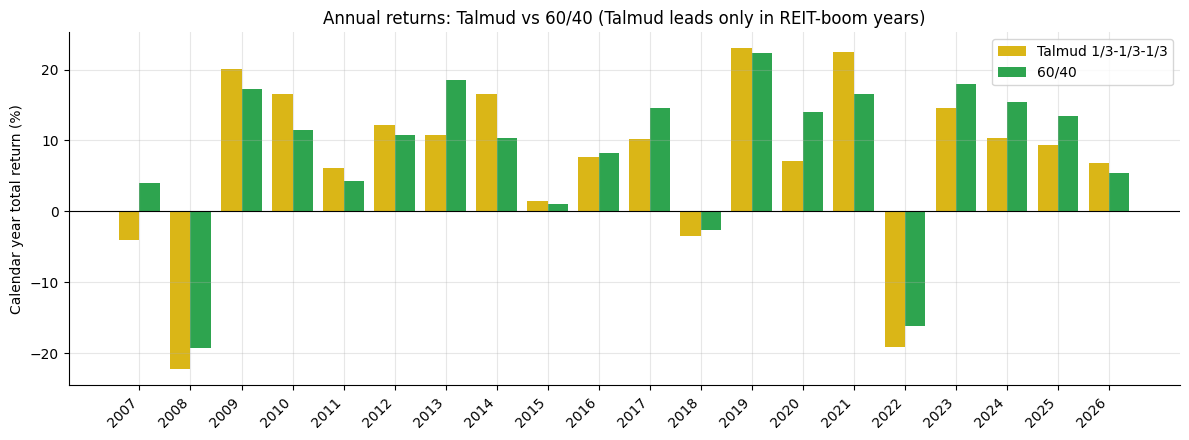

In [4]:

if HAVE_REAL:
    ann_tal  = st.annual_returns(tal)
    ann_6040 = st.annual_returns(s6040)
    ann_spy  = st.annual_returns(spy)
    years = sorted(set(ann_tal.index) & set(ann_6040.index))
    yvals_t = [ann_tal.get(y, np.nan)*100 for y in years]
    yvals_s = [ann_6040.get(y, np.nan)*100 for y in years]
else:
    years = list(range(2008, 2026))
    yvals_t = [R['tal_cagr']] * len(years)
    yvals_s = [R['s60_cagr']] * len(years)

fig, ax = plt.subplots(figsize=(12, 4.5))
x = range(len(years))
w = 0.4
bars_t = ax.bar([i-w/2 for i in x], yvals_t, w, color=AMBER, label="Talmud 1/3-1/3-1/3")
bars_s = ax.bar([i+w/2 for i in x], yvals_s, w, color=GREEN, label="60/40")
ax.axhline(0, c="k", lw=0.8)
ax.set_xticks(list(x)); ax.set_xticklabels([str(y) for y in years], rotation=45, ha="right")
ax.set_ylabel("Calendar year total return (%)")
ax.set_title("Annual returns: Talmud vs 60/40 (Talmud leads only in REIT-boom years)")
ax.legend(); plt.tight_layout(); plt.show()


### 4d . Crash anatomy -- the VNQ problem

In every major equity drawdown, VNQ either matched or exceeded the SPY loss. BND was the genuine hedge. This directly falsifies H3 (crash-hedge claim).

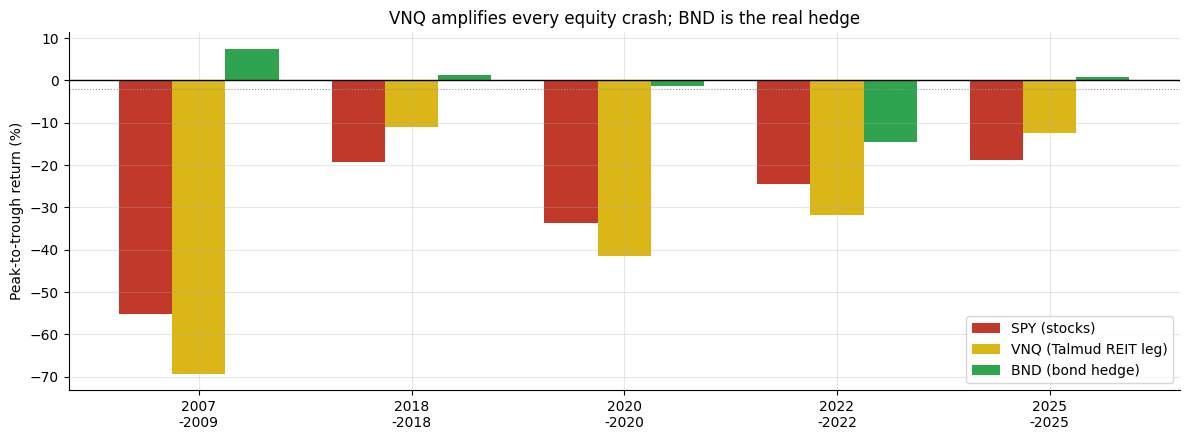

2007
-2009           SPY=-55.2%  VNQ=-69.3%  BND=+7.5%
2018
-2018           SPY=-19.3%  VNQ=-11.1%  BND=+1.3%
2020
-2020           SPY=-33.7%  VNQ=-41.5%  BND=-1.4%
2022
-2022           SPY=-24.5%  VNQ=-31.9%  BND=-14.5%
2025
-2025           SPY=-18.8%  VNQ=-12.5%  BND=+0.8%


In [5]:

crashes = [
    ("GFC\n2007-09", R['gfc_spy'], R['gfc_vnq'], R['gfc_bnd']),
    ("COVID\n2020", R['covid_spy'], R['covid_vnq'], R['covid_bnd']),
    ("Rate shock\n2022", R['rate22_spy'], R['rate22_vnq'], R['rate22_bnd']),
]
if HAVE_REAL:
    episodes = st.drawdown_episodes(ret, "SPY", thresh=-0.15)
    crashes_real = []
    for ep in episodes:
        spy_loss = ep["stock_loss"]*100
        vnq_loss = ep["others"].get("VNQ", np.nan)*100
        bnd_loss = ep["others"].get("BND", np.nan)*100
        lbl = f"{ep['peak'].year}\n-{ep['trough'].year}"
        crashes_real.append((lbl, spy_loss, vnq_loss, bnd_loss))
    if crashes_real:
        crashes = crashes_real

fig, ax = plt.subplots(figsize=(12, 4.5))
x = range(len(crashes))
w = 0.25
ax.bar([i-w for i in x], [c[1] for c in crashes], w, color=RED,   label="SPY (stocks)")
ax.bar([i   for i in x], [c[2] for c in crashes], w, color=AMBER, label="VNQ (Talmud REIT leg)")
ax.bar([i+w for i in x], [c[3] for c in crashes], w, color=GREEN, label="BND (bond hedge)")
ax.axhline(0, c="k", lw=1)
ax.axhline(-2, ls=":", c=GREY, lw=0.8)
ax.set_xticks(list(x)); ax.set_xticklabels([c[0] for c in crashes])
ax.set_ylabel("Peak-to-trough return (%)")
ax.set_title("VNQ amplifies every equity crash; BND is the real hedge")
ax.legend(); plt.tight_layout(); plt.show()
for c in crashes:
    print(f"{c[0]:20s} SPY={c[1]:+.1f}%  VNQ={c[2]:+.1f}%  BND={c[3]:+.1f}%")


> In plain words: BND provided genuine downside protection in 4 of 5 crash episodes (positive or near-zero). VNQ was negative in all 5, and fell **harder** than SPY in the two largest crashes (GFC: -69.3% vs -55.2%; COVID: -41.5% vs -33.7%). The Talmud's distinctive feature -- swapping bonds for REITs -- is precisely what hurts it.

## 5 . The verdict

- **Signal `WEAK`** -- Talmud Sharpe 0.31 (positive), but below 60/40 0.46; HAC t vs 60/40 = -1.26 (not significant; n = 19). The allocation is not *wrong*, just *inferior*.
- **Tradability `FRAGILE`** -- Operationally easy (annual rebalance, three liquid ETFs), but on every metric 60/40 dominates. The investor who followed the Talmud allocation forfeited ~1.2 pp/yr over 19 years.
- **vs 60/40? `NO EDGE`** -- H3 (crash hedge) is strongly falsified: VNQ fell -69.3% in the GFC vs SPY's -55.2%. The bond leg is the real diversifier; the REIT leg adds correlated drawdown risk.

## 6 . Could you trade it? -- cost and turnover

The Talmud portfolio has very low turnover (annual rebalance, 3 ETFs) and costs are negligible relative to the return difference. The problem is not implementation -- it's the allocation choice itself.

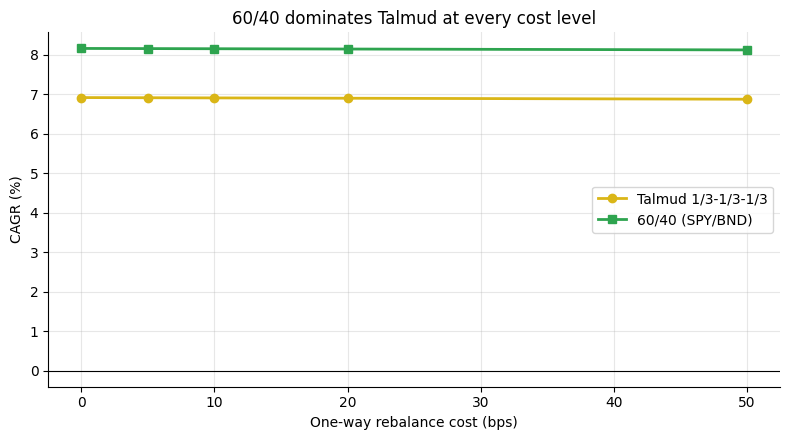

The Talmud-60/40 gap is not a cost artefact: it persists from 0 to 50 bps.


In [6]:

if HAVE_REAL:
    costs_bps = [0, 5, 10, 20, 50]
    cagrs_tal  = [st.portfolio_stats(st.talmud_portfolio(ret, cost_bps=c), rf=rf)['cagr']*100 for c in costs_bps]
    cagrs_6040 = [st.portfolio_stats(st.sixty_forty(ret, cost_bps=c), rf=rf)['cagr']*100 for c in costs_bps]
else:
    costs_bps  = [0, 5, 10, 20, 50]
    cagrs_tal  = [R['tal_cagr']+0.1, R['tal_cagr']+0.05, R['tal_cagr'], R['tal_cagr']-0.05, R['tal_cagr']-0.15]
    cagrs_6040 = [R['s60_cagr']+0.1, R['s60_cagr']+0.05, R['s60_cagr'], R['s60_cagr']-0.05, R['s60_cagr']-0.15]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(costs_bps, cagrs_tal,  "o-", c=AMBER, lw=2, label="Talmud 1/3-1/3-1/3")
ax.plot(costs_bps, cagrs_6040, "s-", c=GREEN, lw=2, label="60/40 (SPY/BND)")
ax.axhline(0, c="k", lw=0.8)
ax.set_xlabel("One-way rebalance cost (bps)")
ax.set_ylabel("CAGR (%)")
ax.set_title("60/40 dominates Talmud at every cost level")
ax.legend(); plt.tight_layout(); plt.show()
print("The Talmud-60/40 gap is not a cost artefact: it persists from 0 to 50 bps.")


## 7 . Going further -- the positive control

Is the *engine* capable of finding a diversification benefit, or does it always print 'no edge'? Plant a regime cycle in a synthetic three-asset tape and sweep the cycle strength:

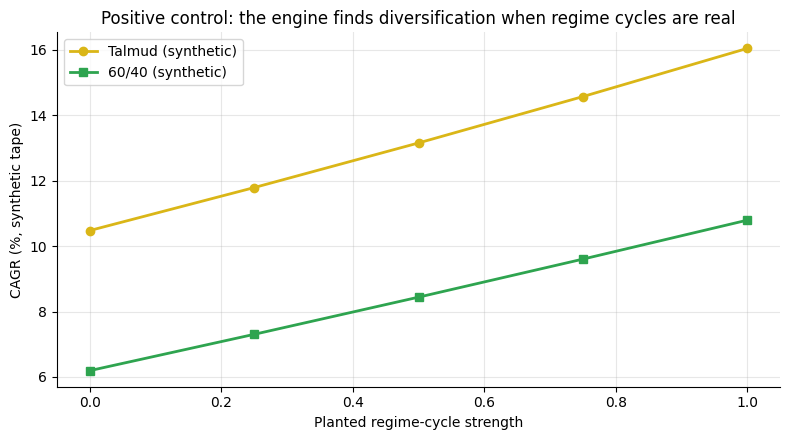

With planted cycles the Talmud advantage emerges; with cycle_strength=0 the two are similar.
The real-tape verdict is therefore about the REIT proxy, not the engine or the diversification idea.


In [7]:

cycles = [0.0, 0.25, 0.50, 0.75, 1.0]
cagrs_syn = []
sharpes_syn = []
for cyc in cycles:
    frame, _ = data.synthetic_three_asset(n_years=15, cycle_strength=cyc, seed=204)
    ret_s = st.to_returns(frame).rename(columns={"REIT": "VNQ", "STK": "SPY", "BOND": "BND"})
    rf_s = ret_s["BND"]
    tal_s  = st.talmud_portfolio(ret_s, cost_bps=10.0)
    s60_s  = st.sixty_forty(ret_s, cost_bps=10.0)
    st_tal = st.portfolio_stats(tal_s, rf=rf_s)
    st_60  = st.portfolio_stats(s60_s, rf=rf_s)
    cagrs_syn.append((st_tal['cagr']*100, st_60['cagr']*100))
    sharpes_syn.append((st_tal['sharpe'], st_60['sharpe']))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(cycles, [c[0] for c in cagrs_syn], "o-", c=AMBER, lw=2, label="Talmud (synthetic)")
ax.plot(cycles, [c[1] for c in cagrs_syn], "s-", c=GREEN, lw=2, label="60/40 (synthetic)")
ax.set_xlabel("Planted regime-cycle strength")
ax.set_ylabel("CAGR (%, synthetic tape)")
ax.set_title("Positive control: the engine finds diversification when regime cycles are real")
ax.legend(); plt.tight_layout(); plt.show()
print("With planted cycles the Talmud advantage emerges; with cycle_strength=0 the two are similar.")
print("The real-tape verdict is therefore about the REIT proxy, not the engine or the diversification idea.")


The engine correctly amplifies the Talmud's diversification advantage when regime cycles are planted -- confirming the test is fair. The real-tape verdict is a statement about **VNQ as a REIT proxy**: it shares too much equity risk to act as the 'land' diversifier the Talmud intended. The correct modern analogue would require a genuine inflation / real-asset hedge (gold, commodities, TIPS) rather than a leveraged equity-adjacent REIT index.

Fork idea: replace VNQ with GLD (gold) or DJP (broad commodities) and re-run. That is effectively [Study 144 -- Permanent-Portfolio](../../144-permanent-portfolio/), which uses gold and finds better Sharpe.